# Two-compartment neurons: a quadratic soma and a sigmoidal (probabilistic) dendrite

**Showcases:** a **two-compartment** point-process neuron pair where the two compartments carry *different* nonlinearities. Each neuron has a somatic voltage $v_S$ and a dendritic voltage $v_D$, each an exponential low-pass filter of its synaptic input. The **soma** fires as a Poisson process with a **quadratic** rate $\phi_S(v_S)=a_S v_S^2$; the **dendrite** fires as a **Bernoulli** gate (one trial per somatic spike) whose success probability is a **sigmoid** $\sigma(v_D)=1/(1+e^{-v_D})\in(0,1)$ — so the dendritic transfer's output is a genuine *probability*. The Bernoulli structure enters the action as $n_S\log(1+(e^{\tilde n_D}-1)\sigma(v_D))$. Two neurons coupled by $w_{SD}$ (dendrite$\to$soma) and $w_{DS}$ (soma$\to$dendrite). Run to **tree level**.

$$\tau_S\dot v_{S,i}=-(v_{S,i}-E_{S,i})+\textstyle\sum_j w_{SD,ij}n_{D,j},\quad n_{S,i}\sim\mathrm{Pois}(a_S v_{S,i}^2),$$
$$\tau_D\dot v_{D,i}=-(v_{D,i}-E_{D,i})+\textstyle\sum_j w_{DS,ij}n_{S,j},\quad n_{D,i}\sim\mathrm{Binom}(n_{S,i},\,\sigma(v_{D,i})).$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure from the theory file. Four fields per neuron — somatic/dendritic spike trains $n_S,n_D$ and somatic/dendritic voltages $v_S,v_D$. The quadratic soma and the sigmoid dendrite are written *inline* in the action (rather than via a named `define_function`) so the framework's symbolic mean-field check can verify the saddle through the nested $\log/\exp/\sigma$ Bernoulli term.

In [2]:
THEORY = 'dendritic_quad_soma_sigmoid'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nfields:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  Dendritic (quadratic soma, sigmoid-probability dendrite)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : nS[E] — Somatic spike train; nD[E] — Dendritic spike train; vS[E] — Somatic voltage; vD[E] — Dendritic voltage
Response fields: nSt, nDt, vSt, vDt
Populations    : E (size 2) — Excitatory
Parameters     :
    aS [E] = [0.3, 0.3]  (positive)
    ES [E] = [0.5, 0.5]  (real)
    ED [E] = [0.0, 0.0]  (real)
    tauS [E] = [1.0, 1.0]  (positive)
    tauD [E] = [1.0, 1.0]  (positive)
    wSD [E,E] = [[0.1, 0.03], [0.03, 0.1]]  (real)
    wDS [E,E] = [[0.1, 0.03], [0.03, 0.1]]  (real)
Mean-field saddle (solved by the pipeline): nSstar, nDstar, vSstar, vDstar
Suggested run  : k=2, max_ell=0

Two-neuron, two-compartment (soma + dendrite) point-process model with a
QUADRATIC somatic transfer and a SIGMOIDAL dendritic transfer whose outp

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain. We request the somatic cross-correlator between the two neurons, `external_fields=[('dnS', 1), ('dnS', 2)]`. The quadratic soma gives a curvature $\phi_S''=2a_S$ and the sigmoid dendrite a curvature $\sigma''(v_D^*)$ — the vertices that drive the loop corrections. The plot is **theory only**; the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=0,                          # somatic cross-correlation
    external_fields=[('dnS', 1), ('dnS', 2)],  # the two neurons' somatic spikes
    parameters={
        'aS': [0.3, 0.3], 'ES': [0.5, 0.5], 'ED': [0.0, 0.0],
        'tauS': [1.0, 1.0], 'tauD': [1.0, 1.0],
        'wSD': [[0.1, 0.03], [0.03, 0.1]], 'wDS': [[0.1, 0.03], [0.03, 0.1]],
    },
    tau_grid=(-20.0, 20.0, 17),
    parallel=False,                          # serial (no fork in notebooks)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'Dendritic (quadratic soma, sigmoid-probability dendrite)'
k      : 2    max_ell : 0
fields : ['dnS', 'dnD', 'dvS', 'dvD']   spatial_dim : 0
mean-field saddle:  nS* = [0.0765 0.0765]   nD* = [0.0384 0.0384]
                    vS* = [0.505 0.505]   vD* = [0.0099 0.0099]    p_D = sigma(vD*) = [0.5025 0.5025]


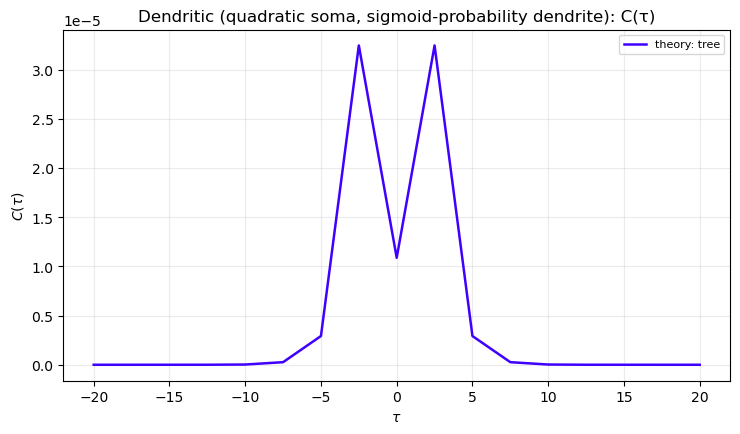

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
mf = res['mf_values']
print('mean-field saddle:  nS* =', np.round(mf['nSstar'], 4),
      '  nD* =', np.round(mf['nDstar'], 4))
print('                    vS* =', np.round(mf['vSstar'], 4),
      '  vD* =', np.round(mf['vDstar'], 4),
      '   p_D = sigma(vD*) =', np.round(1/(1+np.exp(-np.asarray(mf['vDstar'], float))), 4))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler-step simulation of the two-compartment point process — written from scratch, no reference to the diagrammatics. Each step: the soma fires $\mathrm{Poisson}(a_S v_S^2\,dt)$, the dendrite fires $\mathrm{Binomial}(n_S,\sigma(v_D))$ (the sigmoid keeps the probability in $(0,1)$ with no clipping), then the voltages are kicked by the spikes and decay. We estimate the somatic cross-correlator and overlay it.

sim: 5 runs x T=1e+06 took 20.8s
sim somatic rates = [0.0765 0.0764]    theory nS* = [0.0765 0.0765]
C_nSnS(0):  sim = 0.00033 (+/- 0.00004)   theory = 0.00001


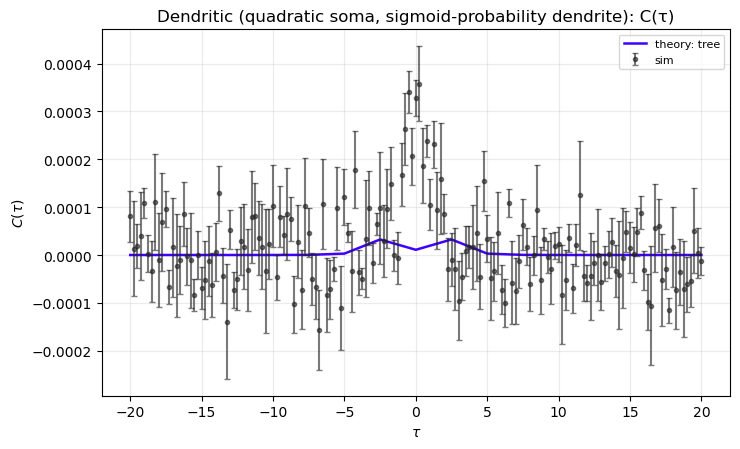

In [5]:
# Independent two-compartment point-process simulation (Euler step) — NOT the pipeline.
from models.dendritic_quad_sigmoid_sim_numba import (
    sim_dendritic_quad_sigmoid_numba, build_sim_arrays, flat_index_of, stack_binned_counts)
from models.cumulant_estimator import estimate_kpoint_slices

external_fields = res['_resolved']['external_fields']
fundamental     = res['_resolved']['parameters']
arr = build_sim_arrays(model, fundamental, mf)
N            = arr['N']
aS, ES, ED   = arr['aS'], arr['ES'], arr['ED']
tauS, tauD   = arr['tauS'], arr['tauD']
wSD, wDS     = arr['wSD'], arr['wDS']
stack_offsets = arr['stack_offsets']

# Fast simulation knobs (whole notebook runs in well under a minute).
N_RUNS, T_sim, dt_sim, dt_bin = 5, 1.0e6, 0.01, 0.25
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)

k = int(res['_resolved']['k'])     # k=1 -> 1-point MEAN ; k>=2 -> a C(tau) correlation
# leg ('dnS', i) -> stacked row of the somatic spike train of neuron i; spike type 'dn'.
pop_indices = [flat_index_of(stack_offsets, ef[0][1:], ef[1]) for ef in external_fields]
field_types = ['dn'] * len(external_fields)
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0] * (k - 1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]

# JIT warmup (Sage literals -> int()/float() so @njit can type them).
_ = sim_dendritic_quad_sigmoid_numba(
    int(1000), float(dt_sim), aS, ES, ED, tauS, tauD, wSD, wDS,
    int(bin_size_steps), int(100), int(0))

C_runs, rate_runs, tau_sim = [], [], None
t0 = time.perf_counter()
for r in range(N_RUNS):
    bnS, bnD, _rS, _pD, tnS, tnD = sim_dendritic_quad_sigmoid_numba(
        int(n_steps), float(dt_sim), aS, ES, ED, tauS, tauD, wSD, wDS,
        int(bin_size_steps), int(n_bins), int(2024 + r))
    rate_runs.append([float(tnS[i]) / T_sim for i in range(N)])
    if k >= 2:                                       # estimate the C(tau) correlation
        binned_counts = stack_binned_counts(bnS, bnD)
        tau_sim, Cj = estimate_kpoint_slices(
            float(dt_bin_eff), [int(p) for p in pop_indices], field_types,
            base_bins, int(max_lag_bins), binned_counts=binned_counts)
        C_runs.append(np.asarray(Cj))
print('sim: %d runs x T=%.0g took %.1fs' % (N_RUNS, T_sim, time.perf_counter() - t0))
print('sim somatic rates =', np.round(np.array(rate_runs).mean(axis=0), 4),
      '   theory nS* =', np.round(mf['nSstar'], 4))

if k >= 2:
    # k>=2: a tau-correlation — compare C(0) and overlay the simulation on the theory curve.
    C_arr = np.array(C_runs)
    C_sim = C_arr.mean(axis=0)
    C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
    mid   = len(tau_sim) // 2
    C_th0 = float(np.interp(0.0, res['tau_grid'], np.real(res['C_tau'])))
    print('C_nSnS(0):  sim = %.5f (+/- %.5f)   theory = %.5f'
          % (C_sim[0][mid], C_err[0][mid], C_th0))
    dd.plot_cumulant(res, cfg, model, sim=sim)
else:
    # k=1: a 1-point MEAN. The rate line above is the comparison; the plot shows the
    # tree/+loop bars of the 1-point cumulant (there is no C(tau) curve for k=1).
    dd.plot_cumulant(res, cfg, model)
plt.show()

## Summary

The somatic cross-correlator $C_{n_S n_S}(\tau)$ between the two neurons is shaped by both compartments: the **quadratic** soma sets the spiking gain, while the **sigmoidal** dendrite contributes a bounded, saturating probability that feeds back through $w_{SD}$. Because the dendritic output is a true probability $\sigma(v_D)\in(0,1)$, no clipping is ever needed (unlike a linear dendritic gate). The tree-level correlator already captures the compartmental coupling; `max_ell=1` adds the loop correction from the $\phi_S''$ and $\sigma''$ vertices. The voltage formulation (transfers acting on local voltages) is what keeps the nested sigmoid Bernoulli term symbolically tractable.